<a href="https://colab.research.google.com/github/habibiputrar/DeepLearning_B_2411531001_Habibi-Putra-Rizqullah/blob/main/Praktikum1/Tugas_Praktikum1_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = torch.FloatTensor(X_train)
y_train = torch.LongTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.LongTensor(y_test)

# Model baseline
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.model(x)

## Tugas Individu: Modifikasi Arsitektur (128-64-32)

Membandingkan arsitektur baseline (64-32) dengan arsitektur yang lebih besar (128-64-32), untuk melihat pengaruh ukuran jaringan terhadap akurasi dan waktu training.

In [2]:
import time

# Arsitektur modifikasi: 128 -> 64 -> 32
class MLP_Modified(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MLP_Modified, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    def forward(self, x):
        return self.model(x)

torch.manual_seed(42)
model_mod = MLP_Modified(4, 3)
criterion_mod = nn.CrossEntropyLoss()
optimizer_mod = optim.Adam(model_mod.parameters(), lr=0.01)

losses_mod = []
start = time.time()
for epoch in range(100):
    optimizer_mod.zero_grad()
    outputs = model_mod(X_train)
    loss = criterion_mod(outputs, y_train)
    loss.backward()
    optimizer_mod.step()
    losses_mod.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/100], Loss: {loss.item():.4f}')

train_time_mod = time.time() - start

with torch.no_grad():
    y_pred_mod = torch.argmax(model_mod(X_test), dim=1)
    acc_mod = accuracy_score(y_test, y_pred_mod)

print(f'\nWaktu training: {train_time_mod:.4f}s')
print(f'Akurasi Model (128-64-32): {acc_mod:.4f}')

Epoch [10/100], Loss: 0.2174
Epoch [20/100], Loss: 0.0516
Epoch [30/100], Loss: 0.0356
Epoch [40/100], Loss: 0.0266
Epoch [50/100], Loss: 0.0159
Epoch [60/100], Loss: 0.0078
Epoch [70/100], Loss: 0.0032
Epoch [80/100], Loss: 0.0015
Epoch [90/100], Loss: 0.0008
Epoch [100/100], Loss: 0.0005

Waktu training: 0.3126s
Akurasi Model (128-64-32): 1.0000


In [6]:
# Ukur waktu training baseline
import time as _time

torch.manual_seed(42)
model_base = MLP(4, 3)
criterion_base = nn.CrossEntropyLoss()
optimizer_base = optim.Adam(model_base.parameters(), lr=0.01)

losses_base = []
start = _time.time()
for epoch in range(100):
    optimizer_base.zero_grad()
    outputs = model_base(X_train)
    loss = criterion_base(outputs, y_train)
    loss.backward()
    optimizer_base.step()
    losses_base.append(loss.item())
train_time_base = _time.time() - start

with torch.no_grad():
    y_pred_base = torch.argmax(model_base(X_test), dim=1)
    acc_base = accuracy_score(y_test, y_pred_base)

n_params_base = sum(p.numel() for p in model_base.parameters())
n_params_mod = sum(p.numel() for p in model_mod.parameters())

print(f'Baseline (64-32)      | Params: {n_params_base} | Waktu: {train_time_base:.4f}s | Akurasi: {acc_base:.4f}')
print(f'Modifikasi (128-64-32)| Params: {n_params_mod} | Waktu: {train_time_mod:.4f}s | Akurasi: {acc_mod:.4f}')

Baseline (64-32)      | Params: 2499 | Waktu: 0.3731s | Akurasi: 1.0000
Modifikasi (128-64-32)| Params: 11075 | Waktu: 0.3126s | Akurasi: 1.0000


In [7]:
import pandas as pd

hasil = pd.DataFrame({
    'Arsitektur': ['Baseline (64-32)', 'Modifikasi (128-64-32)'],
    'Jumlah Parameter': [n_params_base, n_params_mod],
    'Waktu Training (s)': [round(train_time_base, 4), round(train_time_mod, 4)],
    'Loss Akhir': [round(losses_base[-1], 4), round(losses_mod[-1], 4)],
    'Akurasi Test': [acc_base, acc_mod],
})
hasil

,Arsitektur,Jumlah Parameter,Waktu Training (s),Loss Akhir,Akurasi Test
0,Baseline (64-32),2499,0.3731,0.0107,1.0
1,Modifikasi (128-64-32),11075,0.3126,0.0005,1.0


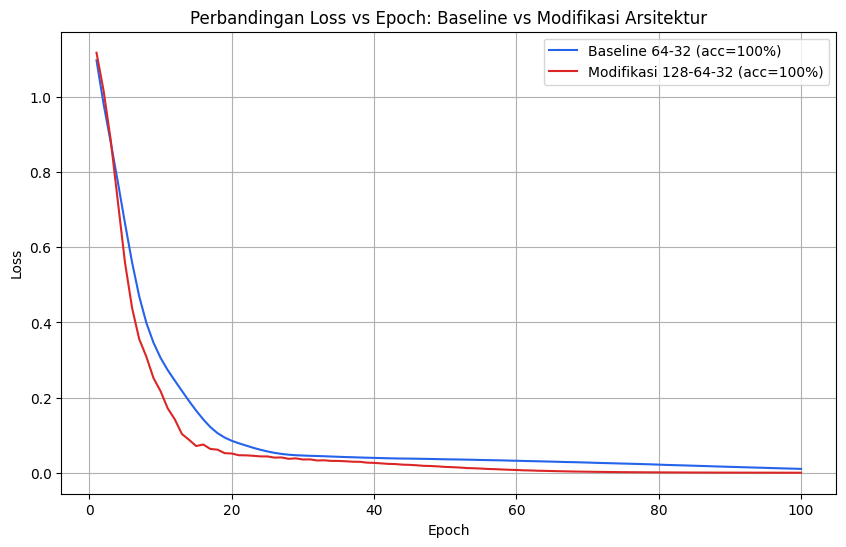

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(losses_base)+1), losses_base, label=f'Baseline 64-32 (acc={acc_base:.0%})', color='#2563eb')
plt.plot(range(1, len(losses_mod)+1), losses_mod, label=f'Modifikasi 128-64-32 (acc={acc_mod:.0%})', color='#dc2626')
plt.title('Perbandingan Loss vs Epoch: Baseline vs Modifikasi Arsitektur')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Akurasi model awal: 1.0000
Waktu training model awal: 0.3731 detik
Akurasi model modifikasi: 1.0000
Waktu training model modifikasi: 0.3126 detik


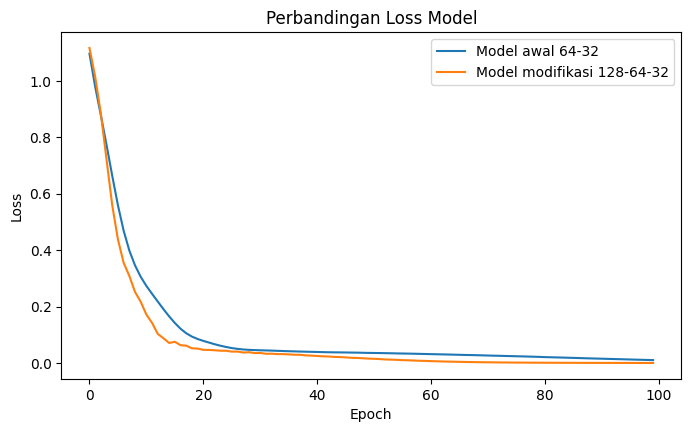

In [13]:
print(f'Akurasi model awal: {acc_base:.4f}')
print(f'Waktu training model awal: {train_time_base:.4f} detik')
print(f'Akurasi model modifikasi: {acc_mod:.4f}')
print(f'Waktu training model modifikasi: {train_time_mod:.4f} detik')

plt.figure(figsize=(8, 4.5))
plt.plot(losses_base, label='Model awal 64-32')
plt.plot(losses_mod, label='Model modifikasi 128-64-32')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Perbandingan Loss Model')
plt.legend()
plt.show()